In [1]:

import tensorflow as tf
tf.config.set_visible_devices([], 'GPU')  # Disable GPU temporarily to reconfigure
gpus = tf.config.list_physical_devices('GPU')

import os
import pandas as pd
import librosa 
import numpy as np
from utils import apply_bandpass_filter, get_labels, get_optimizer, get_monitor, best_threshold_binary, predict_with_two_thresholds, fit_thresholds_one_vs_rest

# mehrklassen probieren
# loss funktion recherchieren
# verschiedene Window Größen

WINDOW_LENGTH = 0.5

data = "../features-extraction/features-relative.csv"
signals_folder = "../data/Spontanaktivität"
signals = {}

for file in os.listdir(signals_folder):
    file_path = os.path.join(signals_folder, file)
    signal, fs = librosa.load(file_path)
    signal = apply_bandpass_filter(signal, fs)
    signals[file] = signal

df = pd.read_csv(data)

labels = get_labels(df)

2026-02-12 11:00:11.778096: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-12 11:00:11.847729: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
training_df = pd.DataFrame(columns=["file", "segment", "signal", "labels"])

def slice_signal(signal, fs, window_seconds):
    window_len = int(window_seconds * fs)
    slices = []

    for start in range(0, len(signal), window_len):
        end = start + window_len
        chunk = signal[start:end]

        if len(chunk) < window_len:
            padding = window_len - len(chunk)
            chunk = np.pad(chunk, (0, padding))
        
        slices.append(chunk)

    return slices

def generate_sample_labels(annotations, window_start, window_end, fs):
   
    window_length = int((window_end - window_start) * fs)
    labels_array = np.zeros(window_length, dtype=np.int32)

    for ann in annotations:
        event_start = ann["start"]
        event_end = ann["end"]

        # Skip if annotation doesn't overlap with this window
        if event_end <= window_start or event_start >= window_end:
            continue 
        
        # Calculate the overlap between annotation and window
        # Clip to window boundaries
        overlap_start = max(event_start, window_start)
        overlap_end = min(event_end, window_end)
        
        # Convert to sample indices within THIS window (relative to window start)
        start_idx = int((overlap_start - window_start) * fs)
        end_idx = int((overlap_end - window_start) * fs)
        
        # Ensure indices are within bounds
        start_idx = max(0, min(start_idx, window_length))
        end_idx = max(0, min(end_idx, window_length))
        
        # Mark the overlapping region as positive
        if start_idx < end_idx:
            if ann["label"] == "Fibrillation":
                labels_array[start_idx:end_idx] = 1
            if ann["label"] == "PSW":
                labels_array[start_idx:end_idx] = 2
    
    return labels_array

for file in labels.keys():
    signal = signals[file[25:]]
    slices = slice_signal(signal, fs, WINDOW_LENGTH)
    index = 0
    for slice in slices:

        try:
            window_start = index * WINDOW_LENGTH
            window_end = window_start + WINDOW_LENGTH
            segment_labels = generate_sample_labels(labels[file], window_start, window_end, fs)
            print(segment_labels)
            training_df.loc[len(training_df)] = {
            "file": file,
            "segment": index,
            "signal": slice,
            "labels": segment_labels
            }
            index += 1
        except Exception as e:
            print(f"Error: {e}")
            pass


[2 2 2 ... 0 0 0]
[0 0 0 ... 0 0 0]
[0 0 0 ... 0 0 0]
[0 0 0 ... 0 0 0]
[0 0 0 ... 0 0 0]
[0 0 0 ... 2 2 2]
[2 2 2 ... 0 0 0]
[0 0 0 ... 2 2 2]
[2 2 2 ... 0 0 0]
[0 0 0 ... 0 0 0]
[0 0 0 ... 0 0 0]
[0 0 0 ... 0 0 0]
[2 2 2 ... 2 2 2]
[2 2 0 ... 0 0 0]
[0 0 0 ... 2 2 2]
[2 2 2 ... 0 0 0]
[0 0 0 ... 2 2 2]
[2 2 2 ... 2 2 2]
[2 2 2 ... 0 0 0]
[0 1 1 ... 0 0 0]
[0 0 0 ... 0 0 0]
[0 0 0 ... 0 0 0]
[0 0 0 ... 0 0 0]
[0 0 0 ... 0 0 0]
[0 0 0 ... 0 0 0]
[0 0 0 ... 0 0 0]
[0 0 0 ... 0 0 0]
[0 0 0 ... 0 0 0]
[0 0 0 ... 0 0 0]
[0 0 0 ... 0 0 0]
[0 0 0 ... 0 0 0]
[0 0 0 ... 2 2 2]
[2 2 2 ... 0 0 0]
[0 0 0 ... 0 0 0]
[0 0 0 ... 2 2 2]
[2 2 2 ... 0 0 0]
[0 0 0 ... 0 0 0]
[0 0 0 ... 0 0 0]
[0 0 0 ... 0 0 0]
[0 0 0 ... 0 0 0]
[0 0 0 ... 0 0 0]
[0 0 0 ... 0 0 0]
[0 0 0 ... 0 0 0]
[0 0 0 ... 2 2 2]
[2 2 2 ... 2 2 2]
[2 2 2 ... 2 2 2]
[2 2 2 ... 0 0 0]
[0 0 0 ... 0 0 0]
[0 0 0 ... 0 0 0]
[0 0 0 ... 0 0 0]
[0 0 0 ... 0 0 0]
[0 0 0 ... 0 0 0]
[0 0 0 ... 0 0 0]
[0 0 0 ... 2 2 2]
[2 2 2 ... 0 0 0]
[0 0 0 ...

In [3]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Dropout, BatchNormalization, Flatten, Dense
from tensorflow.keras.models import Sequential

x = training_df["signal"].tolist()
y = training_df["labels"].tolist()

x = np.array(x)  
windos_samples = int(WINDOW_LENGTH * fs)
x = x.reshape(-1, windos_samples, 1)  

max_seq_len = max(len(seq) for seq in y) if y else windos_samples
print(f"Max label sequence length: {max_seq_len}, window samples: {windos_samples}")

y = np.array(y)  

print(f"y shape after padding: {y.shape}")

x = x / np.max(np.abs(x))

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.20, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    x_train, y_train, test_size=0.10, random_state=42
)
model = Sequential([
    Conv1D(32, 7, activation='relu', padding='same',
           input_shape=(int(WINDOW_LENGTH*fs), 1)),
    Conv1D(64, 5, activation='relu', padding='same'),
    Conv1D(3, 1, activation='softmax', padding='same'),  # 3 classes

])

Max label sequence length: 11025, window samples: 11025
y shape after padding: (175, 11025)


/home/joaquinm/EMG-Thesis/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [4]:
import tensorflow as tf
def weighted_sparse_ce(class_weights):
    w = tf.constant(class_weights, dtype=tf.float32)  # length C

    def loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.int32)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)

        # per-timestep weight from true class
        wt = tf.gather(w, y_true)  # (B,T)

        ce = tf.keras.losses.sparse_categorical_crossentropy(y_true, y_pred)  # (B,T)
        return tf.reduce_mean(ce * tf.cast(wt, ce.dtype))

    return loss


In [5]:

optimizer = get_optimizer()
monitor = get_monitor()

# loss = weighted_sparse_ce([1.0, 12.2, 2.3])  #

# model.compile(optimizer=optimizer,
#               loss="sparse_categorical_crossentropy",
#               metrics=['acc'])

In [6]:
from sklearn.utils import shuffle

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['sparse_categorical_accuracy']
)
X_train, y_train = shuffle(X_train, y_train, random_state=42)
history = model.fit(X_train, y_train,
                    epochs=100,
                    batch_size=2,
                    validation_data=(X_val, y_val),
                    callbacks=[monitor],
                    )

Epoch 1/100


2026-02-12 11:00:17.300927: I external/local_xla/xla/service/service.cc:163] XLA service 0x7105a000ae60 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
2026-02-12 11:00:17.300964: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): Host, Default Version
2026-02-12 11:00:17.329552: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.


 7/63 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 1.0927 - sparse_categorical_accuracy: 0.6198

I0000 00:00:1770894017.693937  450627 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - loss: 0.8434 - sparse_categorical_accuracy: 0.7527 - val_loss: 0.7026 - val_sparse_categorical_accuracy: 0.7457
Epoch 2/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.6478 - sparse_categorical_accuracy: 0.7723 - val_loss: 0.6941 - val_sparse_categorical_accuracy: 0.7603
Epoch 3/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.6330 - sparse_categorical_accuracy: 0.7817 - val_loss: 0.6915 - val_sparse_categorical_accuracy: 0.7636
Epoch 4/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.6194 - sparse_categorical_accuracy: 0.7860 - val_loss: 0.6916 - val_sparse_categorical_accuracy: 0.7626
Epoch 5/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.6119 - sparse_categorical_accuracy: 0.7883 - val_loss: 0.6899 - val_sparse_categorical_accuracy: 0.7607
Epoch 6/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.6087 - sparse_categorical_accuracy: 0.7871 - val_loss: 0.6842 - val_sparse_categorical_accuracy: 0.7611
Epoch 7/100
63/6

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
from scipy.ndimage import binary_dilation
from sklearn.metrics import classification_report

from utils import (
    plot_training_history,
    plot_confusion_matrix,
    find_optimal_threshold,
    get_extended_report
)

# plot_training_history(history)

# --- 1) learn thresholds on validation ---
y_prob_val = model.predict(X_val, verbose=0)  # (B,T,3)
thr = fit_thresholds_one_vs_rest(y_val, y_prob_val, metric="f2", n_steps=1000)

t_fib = thr[1]["t"] 
t_psw = thr[2]["t"]
t_fib += 0.029
t_psw += 0.049

# t_fib = max(t_fib, 0.02)
# t_psw = max(t_psw, 0.08)
print(f"Chosen thresholds -> Fibrillation (1): {t_fib:.4f}, PSW (2): {t_psw:.4f}")



# optimal_threshold = find_optimal_threshold(y_true, y_score)

# y_pred_binary = (y_score > optimal_threshold).astype(int)
# y_pred_binary = (y_score > 0.6).astype(int)

# kernel = 100
# y_pred_smoothed = binary_dilation(y_pred_binary, iterations=kernel)
# --- 2) predict on test with thresholds ---
y_prob_test = model.predict(x_test, verbose=0)       # (N,T,3)
y_pred = predict_with_two_thresholds(
    y_prob_test,
    t_fib,
    t_psw
)                                                    # (N,T)

# --- flatten ---
y_true_flat = y_test.reshape(-1)
y_pred_flat = y_pred.reshape(-1)

# # --- map to binary ---
# # 0 = Negative, 1 = Positive (Fib or PSW)
# y_true_bin = (y_true_flat != 0).astype(int)
# y_pred_bin = (y_pred_flat != 0).astype(int)

# --- classification report ---
print(classification_report(
    y_true_flat,
    y_pred_flat,
))

# --- confusion matrix ---
plot_confusion_matrix(
    y_true_flat,
    y_pred_flat,
    labels=["Negative", "Fibrillation", "PSW"]
)

# --- binary score: probability of being positive ---
y_score_bin = (
    y_prob_test[..., 1] + y_prob_test[..., 2]
).reshape(-1)

# --- extended metrics ---
get_extended_report(
    y_true=y_true_flat,
    y_pred=y_pred_flat,
    y_score=y_score_bin,
    average="binary"
)

# --- sanity checks ---
print("GT positive rate:", y_true_flat.mean())
print("Pred positive rate:", y_pred_flat.mean())


Chosen thresholds -> Fibrillation (1): 0.0610, PSW (2): 0.1830
              precision    recall  f1-score   support

           0       0.78      0.65      0.71    255325
           1       0.21      0.00      0.01     20866
           2       0.42      0.66      0.51    109684

    accuracy                           0.62    385875
   macro avg       0.47      0.44      0.41    385875
weighted avg       0.65      0.62      0.62    385875



TypeError: plot_confusion_matrix() missing 1 required positional argument: 'labels'

In [ ]:
import numpy as np
from scipy.ndimage import label


def compute_avg_label_segment_length_per_sample(y_test):
    lengths = []
    for sample in y_test:
        labeled, num = label(sample)
        for i in range(1, num + 1):
            lengths.append(np.sum(labeled == i))

    if len(lengths) == 0:
        return 0

    return int(np.round(np.mean(lengths)))


def extend_segments_to_min_length(pred_mask, min_len):
    extended = pred_mask.copy()
    labeled, num = label(pred_mask)

    for seg_id in range(1, num + 1):
        idx = np.where(labeled == seg_id)[0]
        seg_len = len(idx)

        if seg_len >= min_len:
            continue  # never shrink

        center = int(np.round(idx.mean()))
        half = min_len // 2

        start = max(0, center - half)
        end = min(len(pred_mask), start + min_len)
        start = max(0, end - min_len)

        extended[start:end] = 1

    return extended

import tensorflow as tf
from sklearn.metrics import classification_report

from utils import (
    plot_training_history,
    plot_confusion_matrix,
    get_extended_report
)

# plot_training_history(history)

y_score = model.predict(x_test, verbose=0).ravel()
y_true = y_test.flatten()

# THRESHOLD = 0.6
# y_pred_binary = (y_score > THRESHOLD).astype(int)

# avg_len = compute_avg_label_segment_length_per_sample(y_test)

# y_pred_extended = extend_segments_to_min_length(
#     y_pred_binary, avg_len
# )

# print("=== EXTENDED (threshold = 0.6) ===")
# print(classification_report(
#     y_true,
#     y_pred_extended,
#     target_names=["Negative", "Fibrillation", "PSW"]))

# plot_confusion_matrix(
#     y_true,
#     y_pred_extended,
#     ["Negative", "Fibrillation", "PSW"]
# )

# get_extended_report(
#     y_true=y_true,
#     y_pred=y_pred_extended,
#     y_score=y_score,
#     average="macro"
# )



/tmp/ipykernel_367548/2782349863.py:58: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.axvspan(time_ms[i], time_ms[i] + (1000/fs),


ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

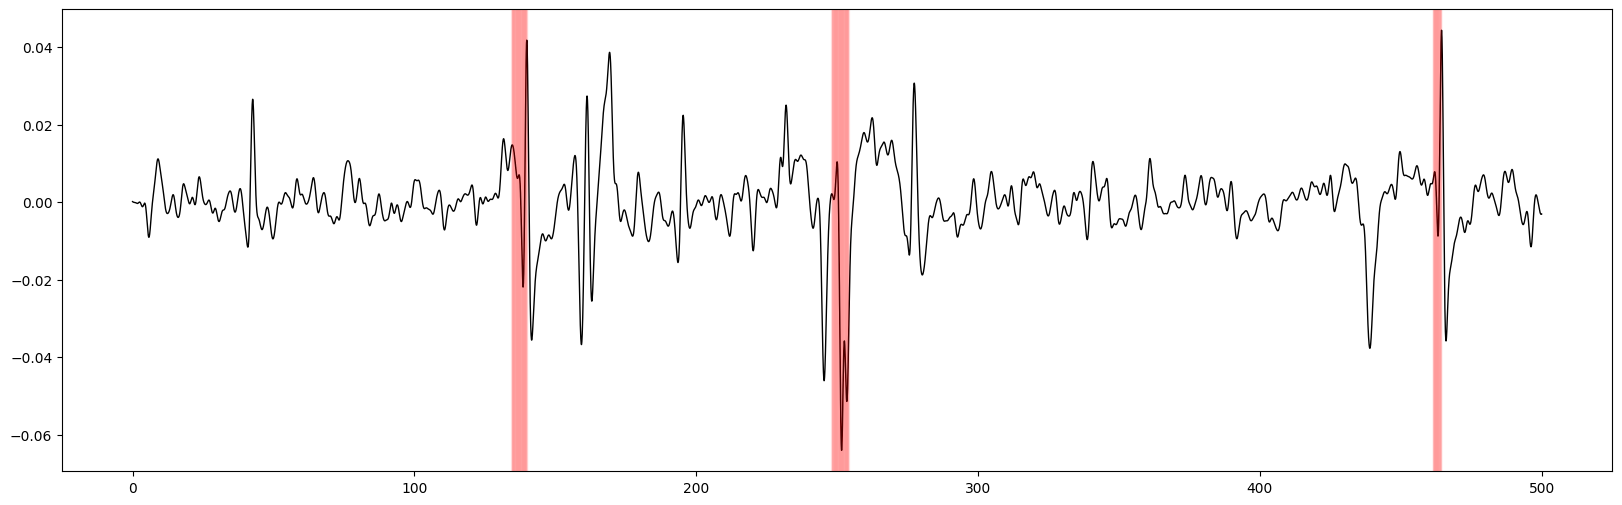

In [ ]:
def format_time_axes(ax, fs, n_samples, ms_major=1000, ms_minor=100, sec_step=0.5):
    """
    Bottom axis: ms (major/minor ticks)
    Top axis: seconds (labels every sec_step seconds).
    """
    time_ms = np.arange(n_samples) / fs * 1000
    x_min, x_max = time_ms[0], time_ms[-1]

    # bottom ticks in ms
    major_start = int(np.ceil(x_min / ms_major) * ms_major)
    major_ticks = np.arange(major_start, x_max + 1, ms_major)
    minor_start = int(np.ceil(x_min / ms_minor) * ms_minor)
    minor_ticks = np.arange(minor_start, x_max + 1, ms_minor)

   

    # top axis in seconds
    ax_top = ax.twiny()
    ax_top.set_xlim(ax.get_xlim())
    sec_ticks = np.arange(0, (x_max / 1000) + sec_step, sec_step)
    ax_top.set_xticks(sec_ticks * 1000)           # positions are in ms
    ax_top.set_xticklabels([f"{t:.2f}s" for t in sec_ticks], fontsize=8)
    ax_top.set_xlabel("Time (s)")
    ax_top.tick_params(axis="x", which="both", length=4)

def plot_multiple_examples(X_test, y_test, model, fs, optimal_threshold, 
                          n_examples=10, ylim_factor=1.5):
 
    # Create output folder
    os.makedirs("Model_Predictions", exist_ok=True)

    for idx in range(min(n_examples, len(X_test))):
        # Get data
        audio = X_test[idx].squeeze()
        labels = y_test[idx].squeeze()

        # Raw model output for this example
        preds_raw = model.predict(X_test[idx:idx+1], verbose=0)[0].squeeze()

        # Apply sigmoid to get probabilities
        preds_prob = tf.nn.sigmoid(preds_raw).numpy()
        
        # Apply optimal threshold
        pred_mask = preds_prob > optimal_threshold

        # Create time axis in milliseconds
        time_ms = np.arange(len(audio)) / fs * 1000

        # Create figure
        fig, ax = plt.subplots(figsize=(20, 6))

        # Plot audio waveform
        ax.plot(time_ms, audio, color='black', linewidth=1, label='Audio Signal', zorder=1)

        # Highlight regions where label = 1 (ground truth events - RED)
        for i in range(len(labels)):
            if labels[i] == 1:
                ax.axvspan(time_ms[i], time_ms[i] + (1000/fs), 
                          color=(1.0, 0.0, 0.0, 0.03), zorder=2, edgecolor='none')

        # Highlight regions where predicted mask == True (predicted events - GREEN)
        for i in range(len(pred_mask)):
            if pred_mask[i]:
                ax.axvspan(time_ms[i], time_ms[i] + (1000/fs), 
                          color=(0.0, 1.0, 0.0, 0.03), zorder=3, edgecolor='none')

        # Set y-axis limits with more space (zoomed out)
        y_min, y_max = audio.min(), audio.max()
        y_range = y_max - y_min
        y_center = (y_max + y_min) / 2
        new_range = y_range * ylim_factor
        ax.set_ylim([y_center - new_range/2, y_center + new_range/2])

        # Get updated y-limits
        y_min_plot, y_max_plot = ax.get_ylim()
        y_mid = (y_min_plot + y_max_plot) / 2

        # Grid: major every 1 second (1000 ms)
        x_min, x_max = time_ms[0], time_ms[-1]
        major_start = int(np.ceil(x_min / 1000) * 1000)
        major_ticks = np.arange(major_start, x_max + 1, 1000)
        ax.set_xticks(major_ticks)

        # Grid: minor every 100 ms for better visibility
        minor_start = int(np.ceil(x_min / 100) * 100)
        minor_ticks = np.arange(minor_start, x_max + 1, 100)
        ax.set_xticks(minor_ticks, minor=True)

            # after plotting the waveform and before grid/tight_layout:
        ax.set_ylabel("Amplitude (volts)")   # add y-axis units

        # format ticks: more second ticks (e.g., every 0.25s)
        format_time_axes(ax, fs, len(audio), ms_major=1000, ms_minor=100, sec_step=0.25)

        # keep or adjust existing grid settings below
        ax.grid(which='major', color='black', linestyle='-', linewidth=1, alpha=0.7)
        ax.grid(which='minor', color='grey', linestyle='-', linewidth=0.6, alpha=0.5)

        # Add time labels for minor ticks
        for x_pos in minor_ticks:
            if x_min < x_pos <= x_max:
                ax.text(x_pos, y_mid, f'{int(x_pos)}', rotation=90, 
                       verticalalignment='center', horizontalalignment='right', 
                       fontsize=7, color='grey', alpha=0.7)


        plt.tight_layout()

        # Save figure
        save_path = os.path.join("./Model_Predictions", f"extended_example_{idx+1}.png")
        plt.savefig(save_path, dpi=300)
        plt.close(fig)
        print(f"Saved: {save_path}")

# Plot predictions with optimal threshold
plot_multiple_examples(x_test, y_test, model, fs, 0.6, 
                       n_examples=10, ylim_factor=1.5)


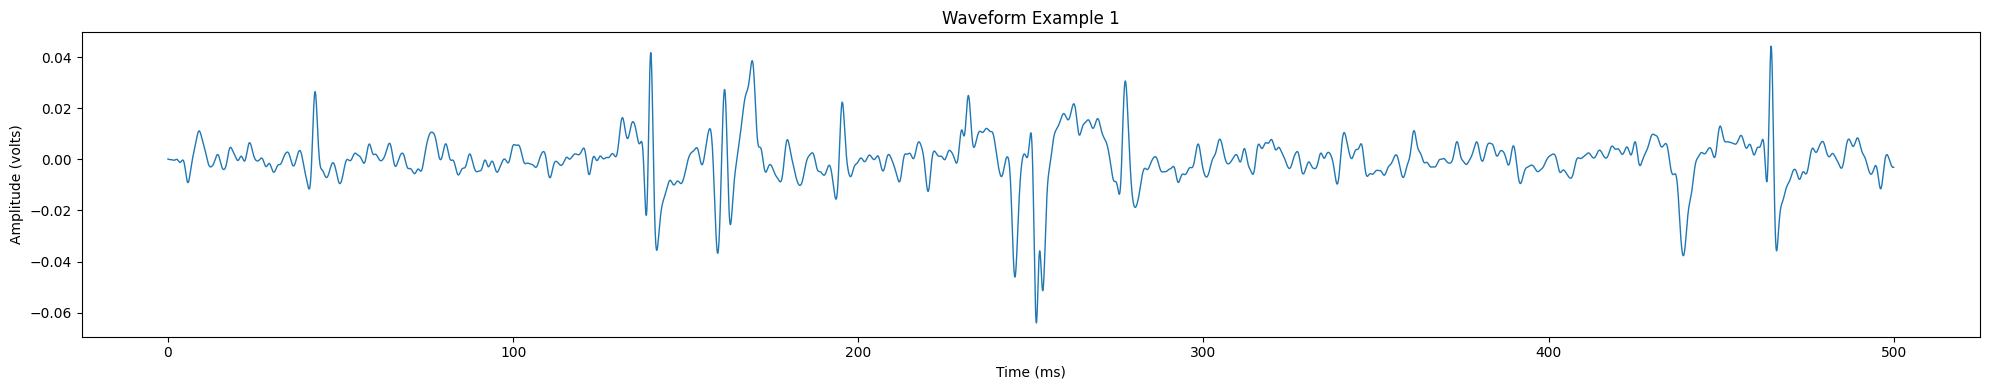

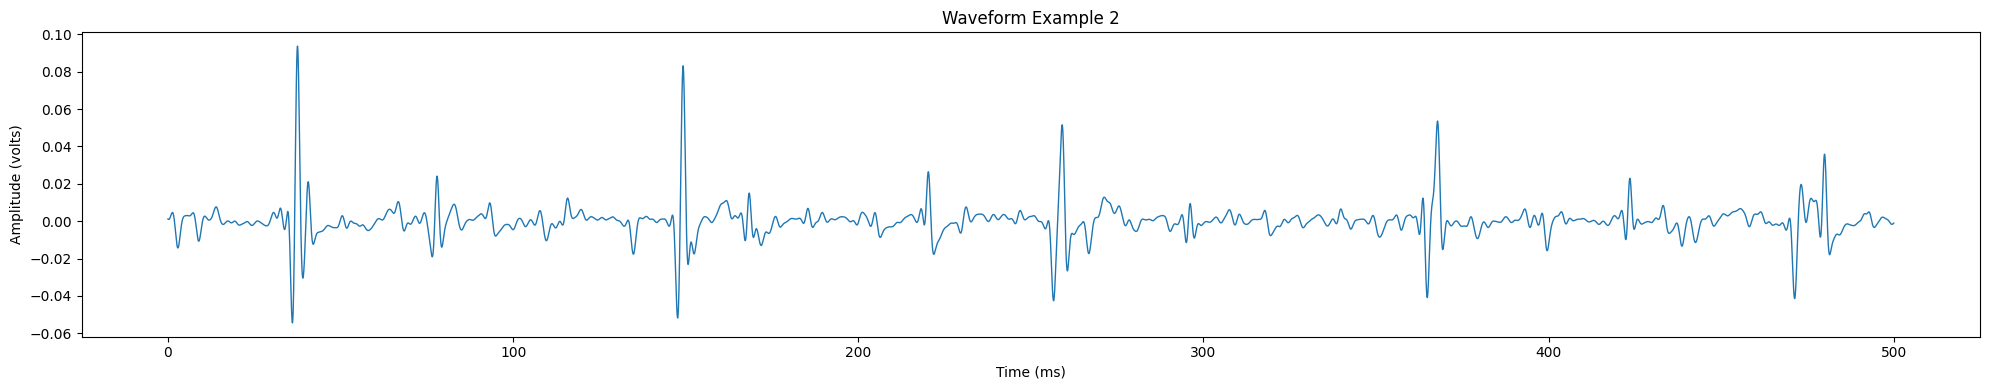

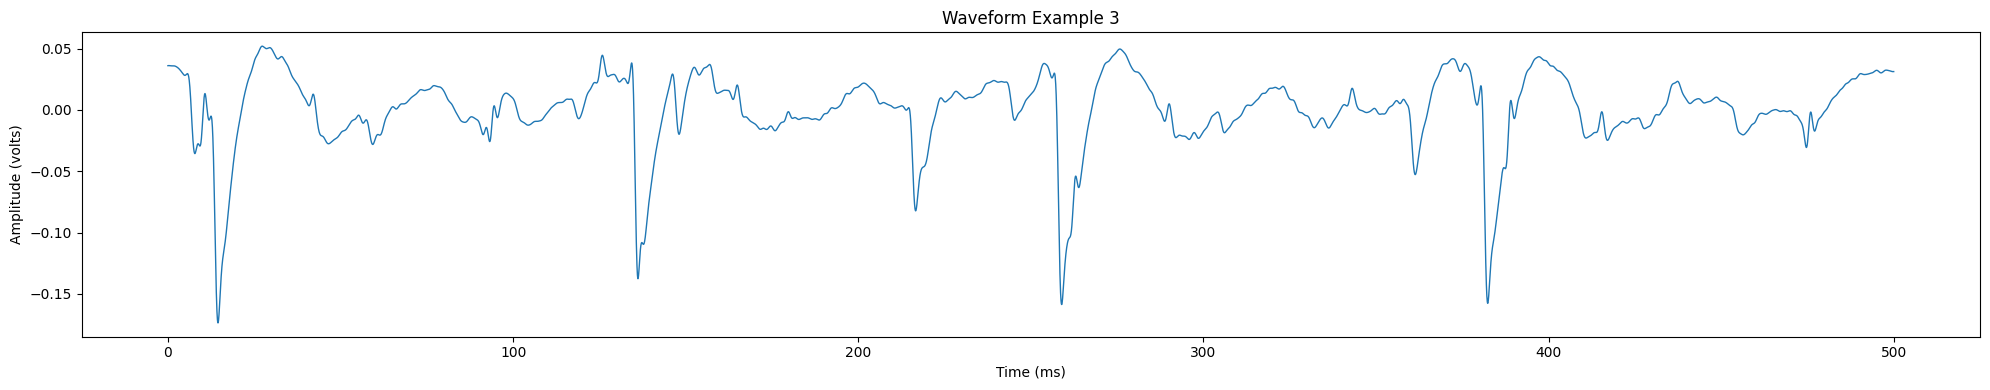

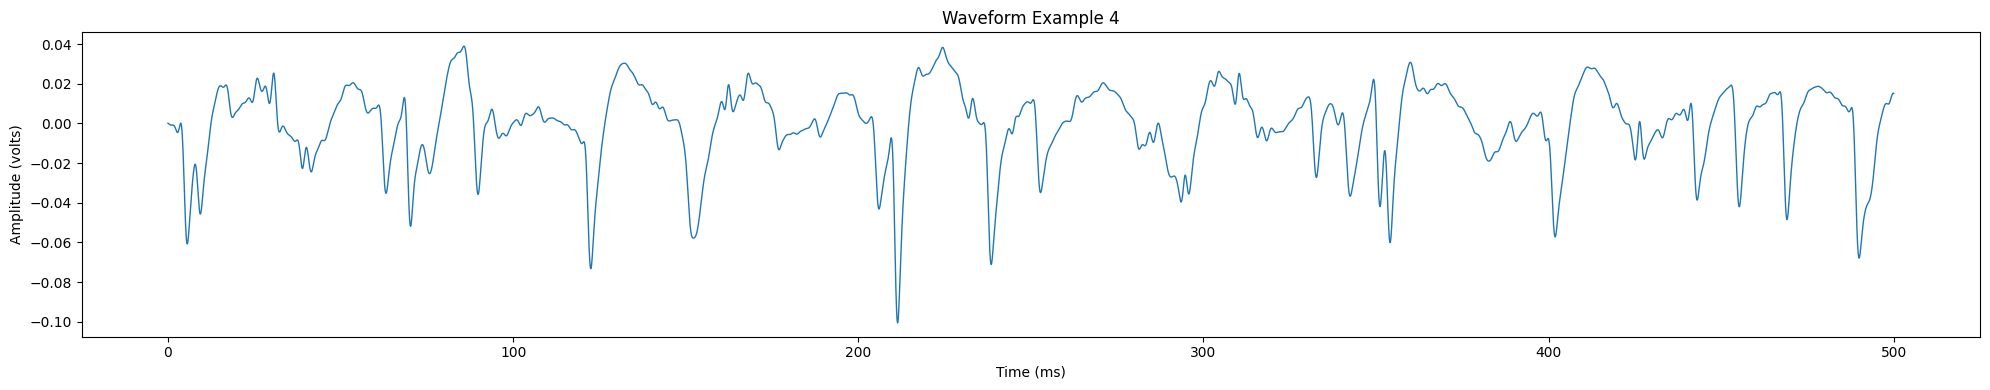

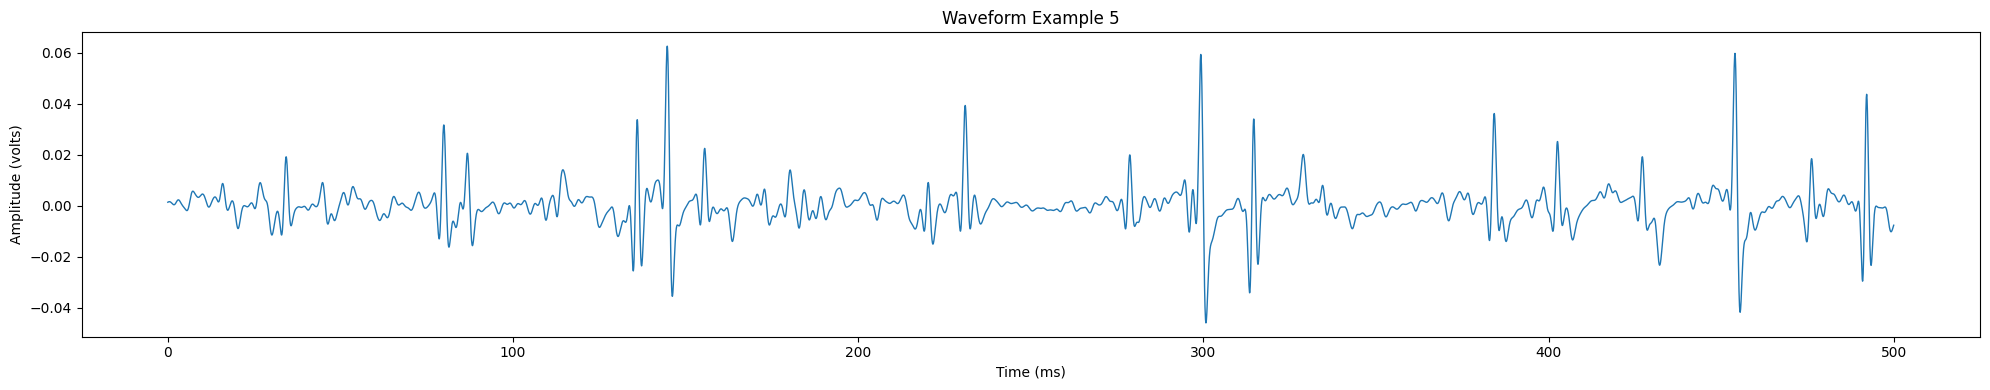

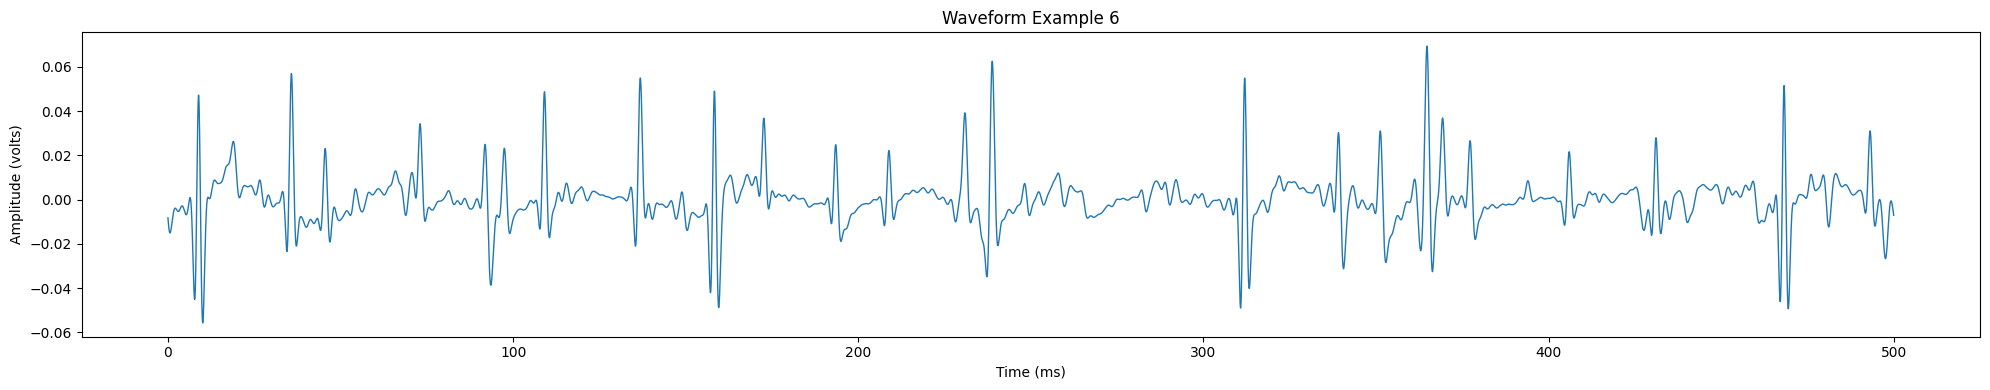

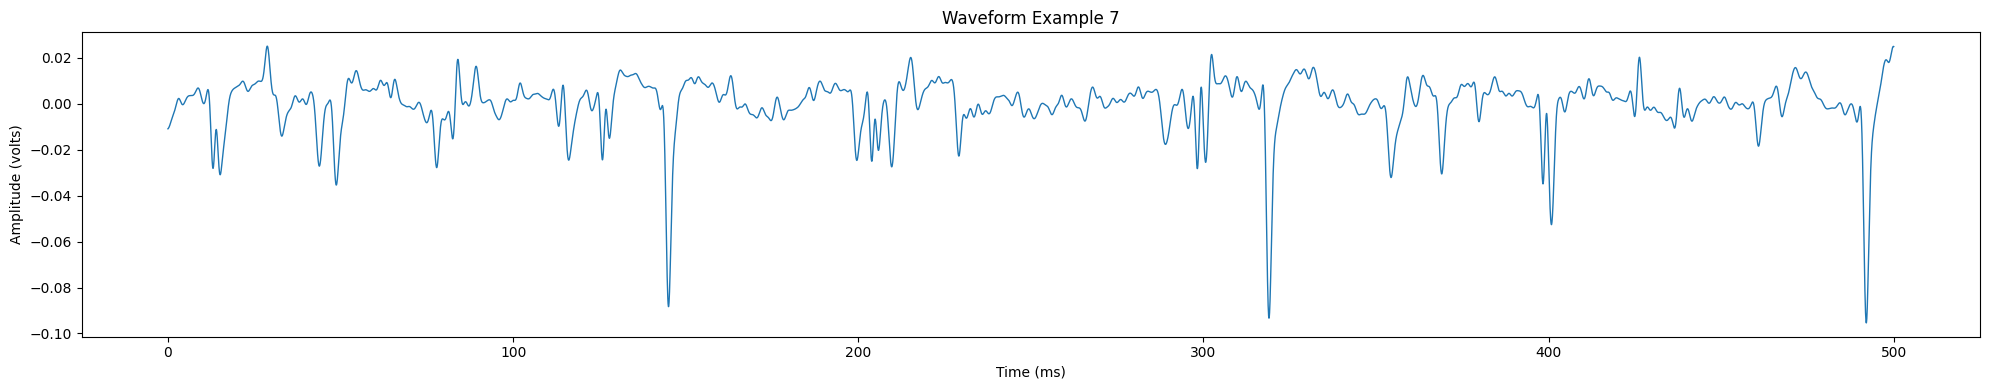

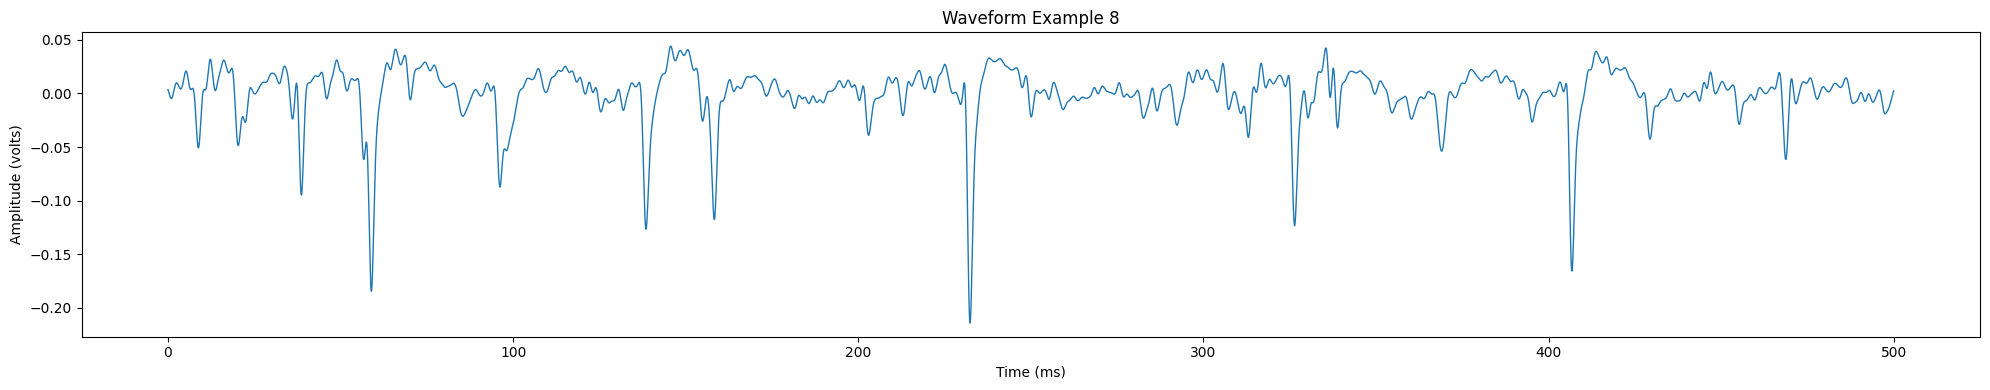

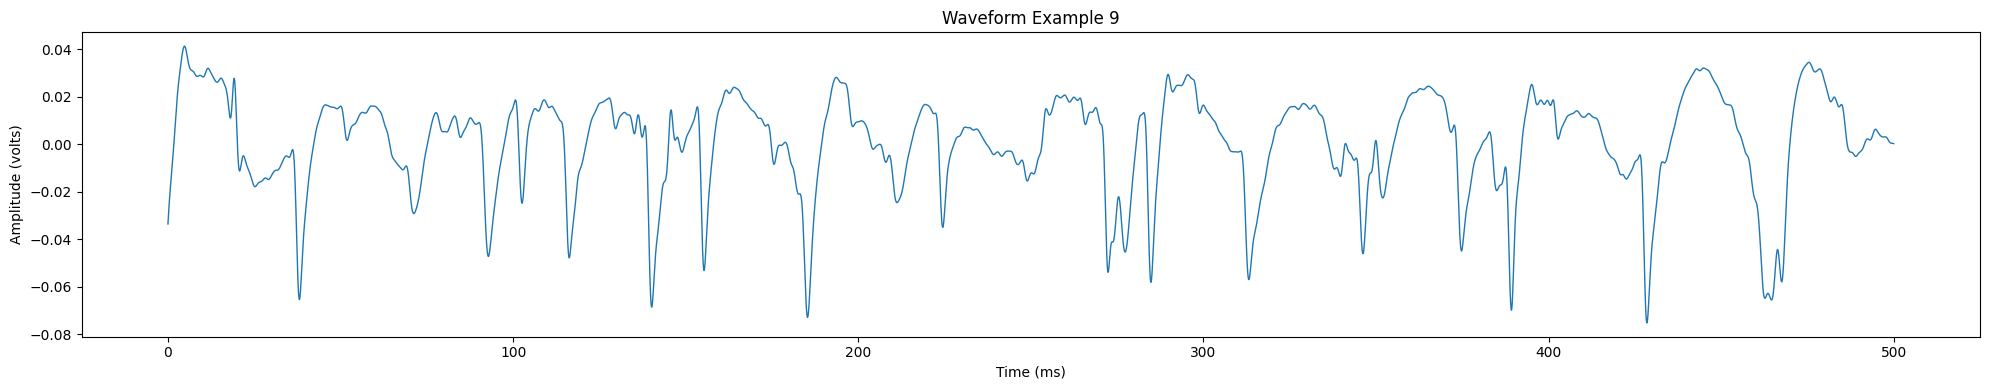

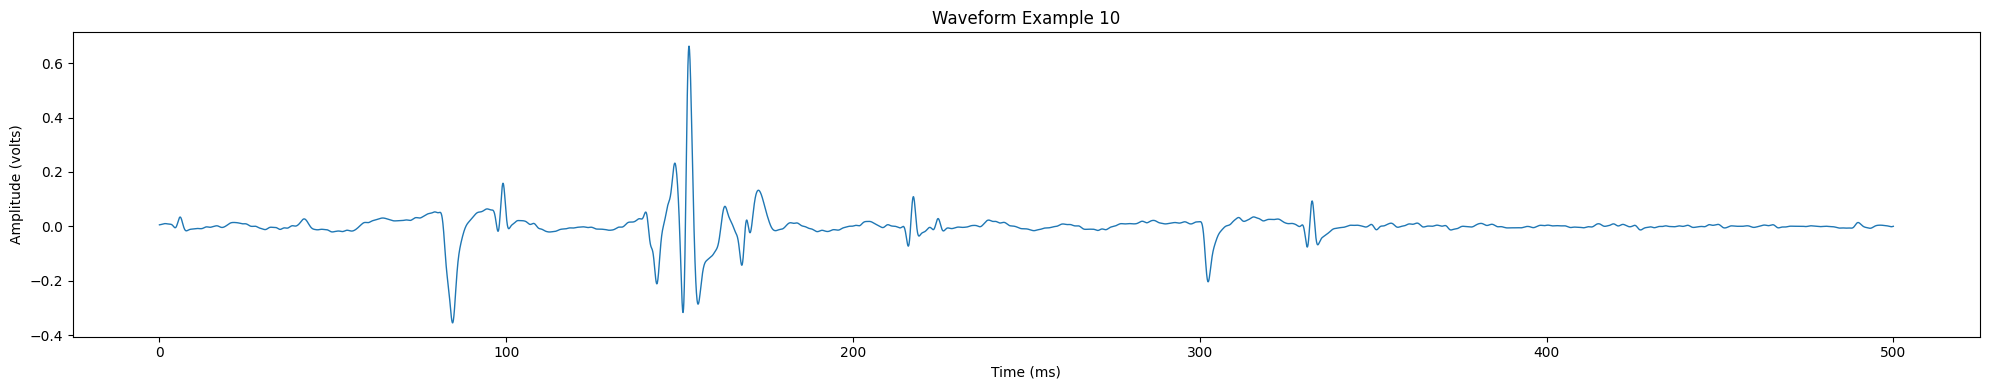

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

def format_time_axes(ax, fs, n_samples, ms_major=1000, ms_minor=100, sec_step=0.5):
    """
    Bottom axis: ms (major/minor ticks)
    Top axis: seconds (labels every sec_step seconds).
    """
    time_ms = np.arange(n_samples) / fs * 1000
    x_min, x_max = time_ms[0], time_ms[-1]

    # bottom ticks in ms
    major_start = int(np.ceil(x_min / ms_major) * ms_major)
    major_ticks = np.arange(major_start, x_max + 1, ms_major)
    minor_start = int(np.ceil(x_min / ms_minor) * ms_minor)
    minor_ticks = np.arange(minor_start, x_max + 1, ms_minor)

    # top axis in seconds
    ax_top = ax.twiny()
    ax_top.set_xlim(ax.get_xlim())
    sec_ticks = np.arange(0, (x_max / 1000) + sec_step, sec_step)
    ax_top.set_xticks(sec_ticks * 1000)           # positions are in ms
    ax_top.set_xticklabels([f"{t:.2f}s" for t in sec_ticks], fontsize=8)
    ax_top.set_xlabel("Time (s)")
    ax_top.tick_params(axis="x", which="both", length=4)

def plot_multiple_waveforms(X, fs, n_examples=10, figsize=(20, 4)):
    """
    Plots only the waveform with clean x/y axes.
    X: array of shape (N, samples, 1) or (N, samples)
    fs: sampling frequency
    """
    for idx in range(min(n_examples, len(X))):
        audio = X[idx].squeeze()
        time_ms = np.arange(len(audio)) / fs * 1000

        plt.figure(figsize=figsize)
        plt.plot(time_ms, audio, linewidth=1)

        plt.xlabel("Time (ms)")
        plt.ylabel("Amplitude (volts)")
        plt.title(f"Waveform Example {idx+1}")

        plt.tight_layout()
        plt.show()

# Run the plotting
plot_multiple_waveforms(
    x_test, fs,
    n_examples=10
)

## Problem Formulation

In this thesis, the task of spontaneous-activity detection is formulated as a **sequence-to-sequence binary labeling problem**. The input EMG signal is represented as a time-ordered sequence of real-valued measurements:

$$
x = \{x_t\}_{t \in \mathbb{N}}, \quad x_t \in \mathbb{R}
$$

Each time frame in the signal corresponds to either  
- **clean muscle activity**, or  
- **spontaneous activity (SA)**.

The ground-truth annotation is therefore a binary sequence:

$$
y = \{y_t\}_{t \in \mathbb{N}}, \quad y_t \in \{0,1\}
$$

with

$$
y_t =
\begin{cases}
1, & \text{if frame } t \text{ contains spontaneous activity}, \\
0, & \text{otherwise}.
\end{cases}
$$

The goal is to learn a parametric model

$$
f_\theta : \mathbb{R}^N \rightarrow \{0,1\}^N
$$

that maps an EMG signal of length \(N\) to a predicted binary sequence:

$$
\hat{y} = f_\theta(x) = \{\hat{y}_t\}_{t \in \mathbb{N}}
$$

Training consists of minimizing a loss function \(L(y, \hat{y})\) that measures the difference between predictions and ground truth:

$$
\theta^{*} = \arg\min_{\theta} \, L(y, \hat{y})
$$

Because spontaneous-activity events are rare compared to clean frames, the dataset is highly imbalanced. To address this, the model is trained using **focal loss**, which increases the relative weight of the positive class (\(y_t = 1\)) and encourages the model to focus on correctly detecting spontaneous activity.


In [ ]:
#N erwähnen: window grösse
# Teta auch erwähnen: Model Parameter also Gewichte
# stern: ideale Gewichte

# In der Zukunft auch für RF und CNN 

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

def plot_training_examples(
    df,
    fs,
    n_examples=6,
    out_dir="Training_Examples",
    random=True,
    model=None,
    threshold=0.5,
    ylim_factor=1.5
):
    """
    Plot examples from `df` (expects columns: 'file','segment','signal','labels').
    - fs: sample rate (int)
    - model: optional Keras model that outputs logits or probabilities per sample
    - threshold: used to binarize model outputs
    """
    os.makedirs(out_dir, exist_ok=True)

    if len(df) == 0:
        print("No examples in df")
        return

    idxs = np.arange(len(df))
    if random:
        np.random.shuffle(idxs)
    idxs = idxs[:min(n_examples, len(df))]

    for i, idx in enumerate(idxs):
        row = df.iloc[idx]
        audio = np.asarray(row["signal"]).squeeze()
        labels = np.asarray(row["labels"]).squeeze()
        labels = (labels > 0.5).astype(int)

        # Optional model prediction
        pred_mask = None
        if model is not None:
            x = audio.reshape(1, -1, 1).astype(np.float32)
            preds = model.predict(x, verbose=0).ravel()
            try:
                probs = tf.nn.sigmoid(preds).numpy()
            except:
                probs = preds  # if model already returns probabilities
            pred_mask = (probs > threshold).astype(int)

        time_ms = np.arange(len(audio)) / fs * 1000

        fig, ax = plt.subplots(figsize=(14, 4))
        ax.plot(time_ms, audio, color="black", linewidth=0.8, label="Signal")

        # Ground-truth shading (RED)
        for j in range(len(labels)):
            if labels[j] == 1:
                ax.axvspan(time_ms[j], time_ms[j] + (1000.0 / fs), color=(1, 0, 0, 0.08), edgecolor="none")

        
        # Nice y limits
        y_min, y_max = audio.min(), audio.max()
        y_center = (y_min + y_max) / 2
        new_range = (y_max - y_min) * ylim_factor
        ax.set_ylim([y_center - new_range / 2, y_center + new_range / 2])

    
        ax.set_ylabel("Amplitude (volts)")
        title = f"{row.get('file', '')} - seg {row.get('segment', idx)}"
        ax.set_title(title)
        ax.legend(handles=[
            plt.Line2D([0], [0], color="black", lw=1, label="Signal"),
            plt.Line2D([0], [0], marker='s', color='w', markerfacecolor=(1,0,0,0.4), markersize=10, label='GT'),
        ])
        print(len(fig.axes))
        plt.tight_layout()

        save_path = os.path.join(out_dir, f"example_{i+1}_seg{row.get('segment', idx)}.png")
        plt.savefig(save_path, dpi=200)
        plt.close(fig)
        print("Saved:", save_path)

plot_training_examples(training_df, fs, n_examples=6, random=True)

/tmp/ipykernel_273187/2978370413.py:58: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.axvspan(time_ms[j], time_ms[j] + (1000.0 / fs), color=(1, 0, 0, 0.08), edgecolor="none")


1
Saved: Training_Examples/example_1_seg1.png
1
Saved: Training_Examples/example_2_seg9.png
1
Saved: Training_Examples/example_3_seg6.png
1
Saved: Training_Examples/example_4_seg5.png
1
Saved: Training_Examples/example_5_seg8.png
1
Saved: Training_Examples/example_6_seg16.png
